In [94]:
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Seaborn style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [95]:
# =========================
# 2. LOAD DATASET
# =========================

file_path = "retail_sales_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully!
Dataset shape: (1000, 9)


In [96]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


## Initial Observation

The dataset has been successfully loaded. The next step is to inspect
its structure, column types, and missing values before performing
the analysis.


In [97]:
# =========================
# 3. INITIAL INSPECTION
# =========================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 1000
Number of columns: 9

Column names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


In [98]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [99]:
date_col = "Date"

print("Date column:", date_col)

# Convert date column to datetime
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

print("Date conversion completed.")
print(df[date_col].head())

Date column: Date
Date conversion completed.
0   2023-11-24
1   2023-02-27
2   2023-01-13
3   2023-05-21
4   2023-05-06
Name: Date, dtype: datetime64[ns]


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [101]:

# Check duplicated rows
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


## Observation

The initial inspection shows the structure of the dataset,  data types,No missing values, and No duplicate records.
i also changed the datatype of the date

Missing values and duplicates should be handled before performing
statistical and visual analysis because they may affect the accuracy
of the results.

In [102]:
# Show all column names exactly as they appear
for i, col in enumerate(df.columns):
    print(i, repr(col))
    

0 'Transaction ID'
1 'Date'
2 'Customer ID'
3 'Gender'
4 'Age'
5 'Product Category'
6 'Quantity'
7 'Price per Unit'
8 'Total Amount'


In [103]:


for col in df.columns:
    if col != col.strip():
        print(repr(col))

In [104]:
# Remove leading and trailing spaces
df.columns = df.columns.str.strip()

# Replace multiple spaces with one space
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)

# Remove commas
df.columns = df.columns.str.replace(',', '', regex=False)

df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [105]:
# Check for leading/trailing spaces in string values
for col in df.select_dtypes(include='object').columns:
    spaces = df[col].astype(str).apply(
        lambda x: x != x.strip()
    ).sum()

    if spaces > 0:
        print(f"{col}: {spaces} values have extra spaces")

In [106]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [107]:
for col in df.columns:
    blank_spaces = df[col].astype(str).str.strip().eq("").sum()

    if blank_spaces > 0:
        print(f"{col}: {blank_spaces} blank/space values")

In [108]:
# =========================
# 5. DESCRIPTIVE STATISTICS
# =========================

numeric_cols = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numeric_cols.tolist())

Numerical columns:
['Transaction ID', 'Age', 'Quantity', 'Price per Unit', 'Total Amount']


In [109]:
# Mean
mean_values = df[numeric_cols].mean()

# Median
median_values = df[numeric_cols].median()

# Mode
mode_values = df[numeric_cols].mode().iloc[0]

# Standard deviation
std_values = df[numeric_cols].std()

statistics_table = pd.DataFrame({
    "Mean": mean_values,
    "Median": median_values,
    "Mode": mode_values,
    "Standard Deviation": std_values
})

statistics_table

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


## Descriptive Statistics Observation

The descriptive statistics provide an overview of the numerical
variables in the dataset.

The mean represents the average value, while the median represents
the middle value. Comparing the mean and median can help identify
whether a variable is skewed.

The standard deviation indicates how widely the values vary around
their average.

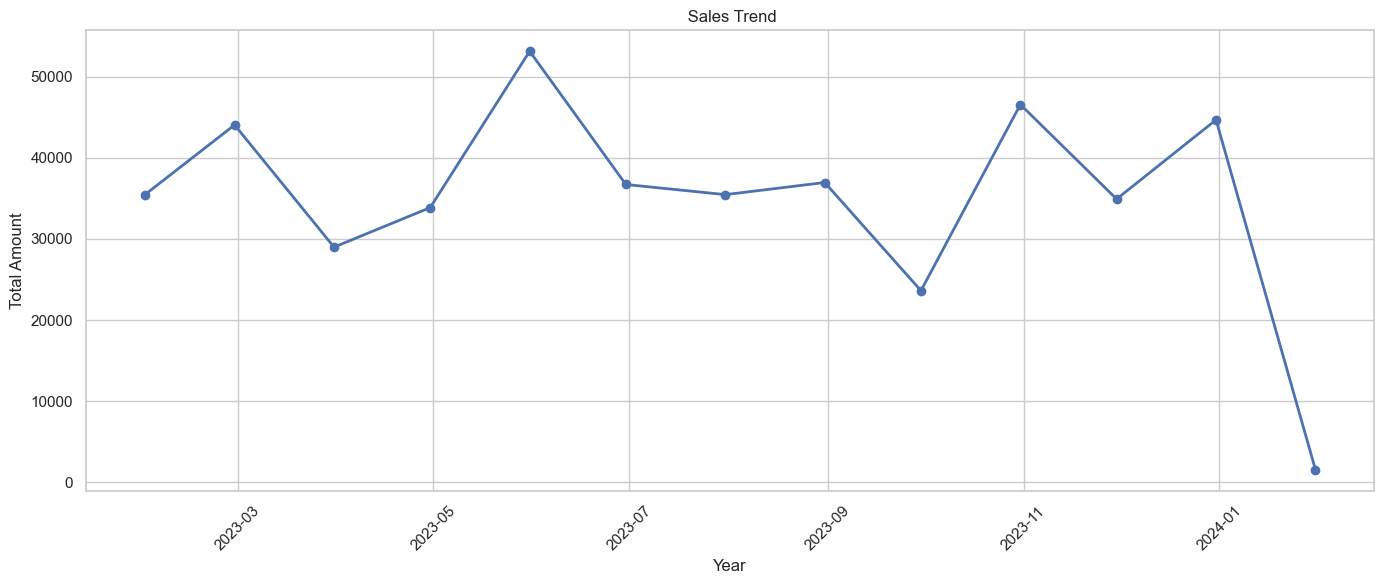

In [110]:
# =========================
# 6. MONTHLY SALES TREND
# =========================
age_col="Age"
sales_col = "Total Amount"
if date_col and sales_col:

    monthly_sales = (
        df.set_index(date_col)[sales_col]
        .resample('ME')
        .sum()
    )

    plt.figure(figsize=(14, 6))

    plt.plot(
        monthly_sales.index,
        monthly_sales.values,
        marker='o',
        linewidth=2
    )

    plt.title(" Sales Trend")
    plt.xlabel("Year")
    plt.ylabel("Total Amount")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

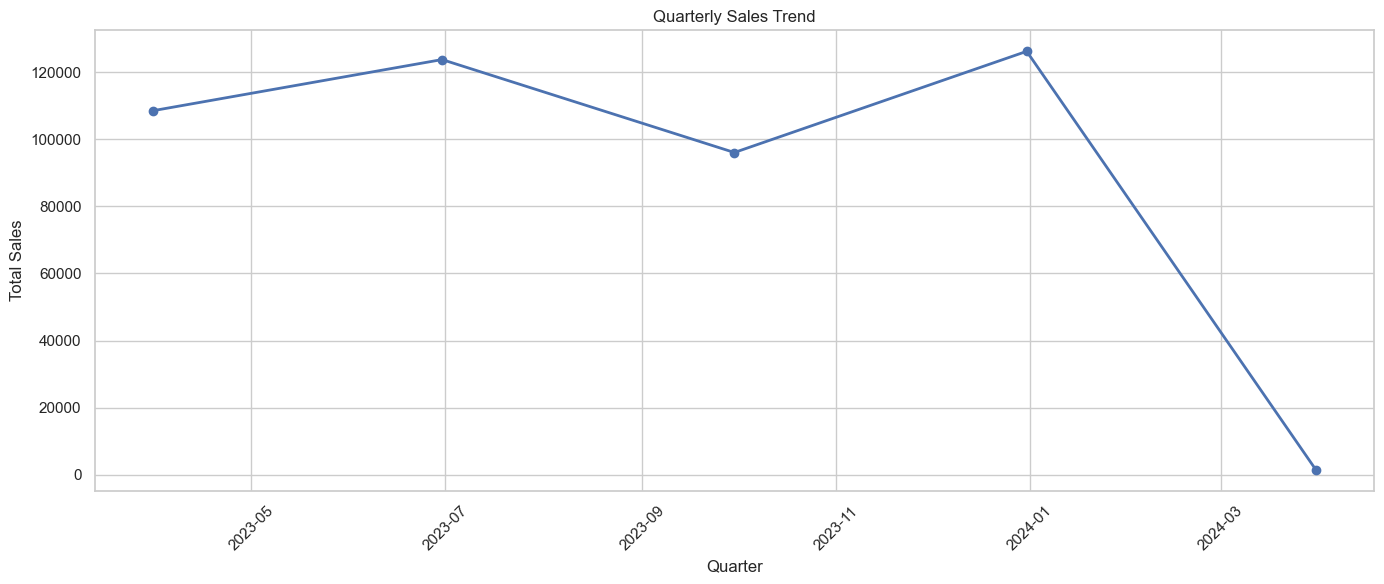

In [111]:
# =========================
# 7. QUARTERLY SALES TREND
# =========================

if date_col and sales_col:

    quarterly_sales = (
        df.set_index(date_col)[sales_col]
        .resample('QE')
        .sum()
    )

    plt.figure(figsize=(14, 6))

    plt.plot(
        quarterly_sales.index,
        quarterly_sales.values,
        marker='o',
        linewidth=2
    )

    plt.title("Quarterly Sales Trend")
    plt.xlabel("Quarter")
    plt.ylabel("Total Sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

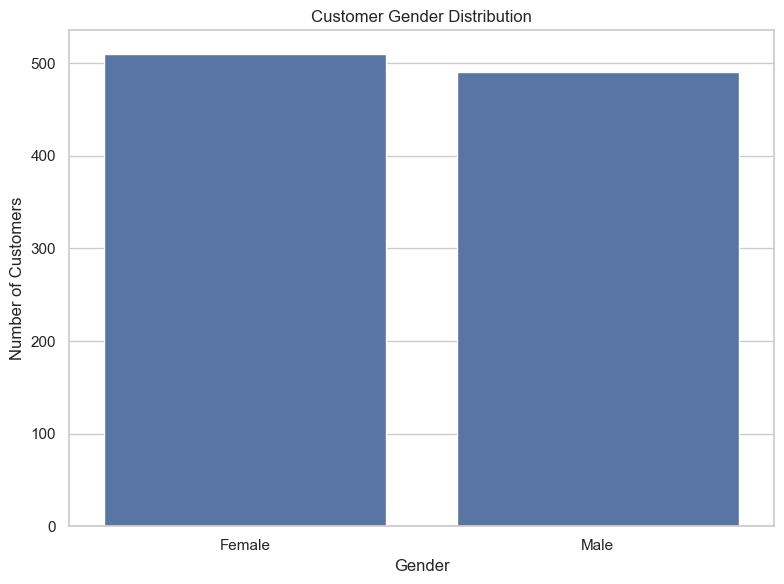

In [112]:
# =========================
# 9. GENDER BREAKDOWN
# =========================
gender_col= "Gender"
if gender_col:

    gender_counts = df[gender_col].value_counts()

    plt.figure(figsize=(8, 6))

    sns.barplot(
        x=gender_counts.index,
        y=gender_counts.values
    )

    plt.title("Customer Gender Distribution")
    plt.xlabel("Gender")
    plt.ylabel("Number of Customers")

    plt.tight_layout()
    plt.show()

In [114]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


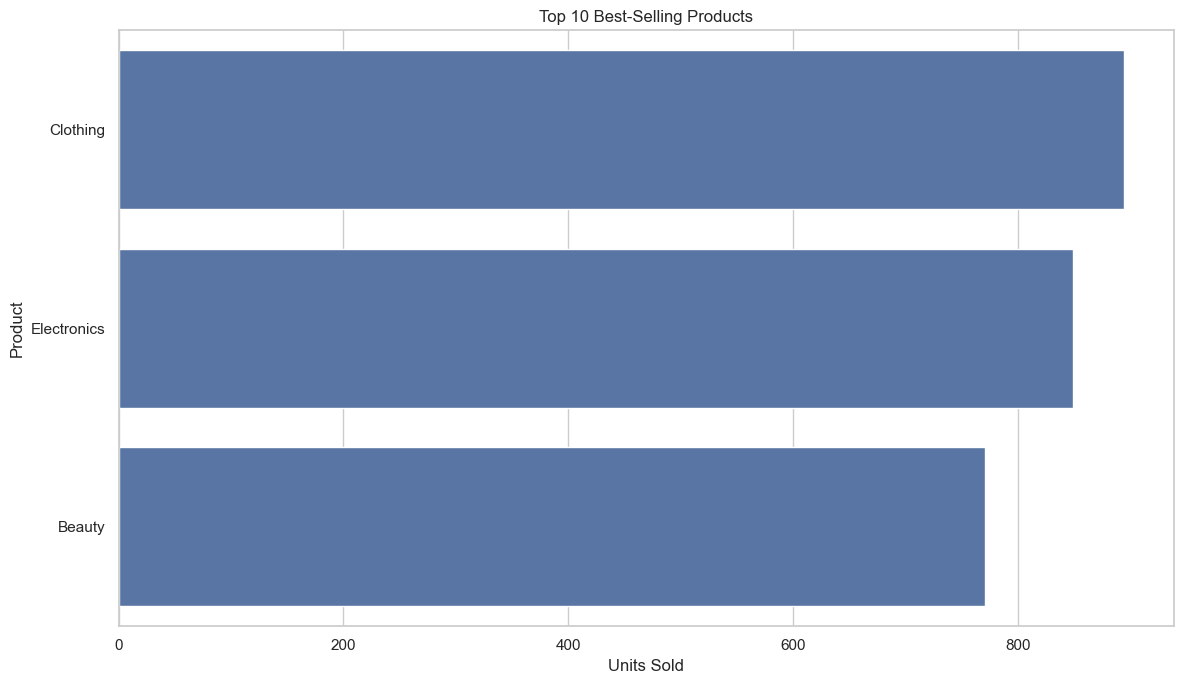

In [119]:
# =========================
# 10. TOP 10 BEST-SELLING PRODUCTS
# =========================
product_col="Product Category"
quantity_col= "Quantity"
if product_col:

    if quantity_col:
        top_products = (
            df.groupby(product_col)[quantity_col]
            .sum()
            .sort_values(ascending=False)
            .head(10)
        )

        y_label = "Units Sold"

    else:
        top_products = (
            df[product_col]
            .value_counts()
            .head(10)
        )

        y_label = "Number of Transactions"

    plt.figure(figsize=(12, 7))

    sns.barplot(
        x=top_products.values,
        y=top_products.index
    )

    plt.title("Top 10 Best-Selling Products")
    plt.xlabel(y_label)
    plt.ylabel("Product")

    plt.tight_layout()
    plt.show()

## Product Performance Observation

The top 10 products reveal which products have the strongest
customer demand.

These products should be monitored closely to avoid stock-outs.
The business can also investigate whether these products can be
bundled with lower-performing products to increase sales.


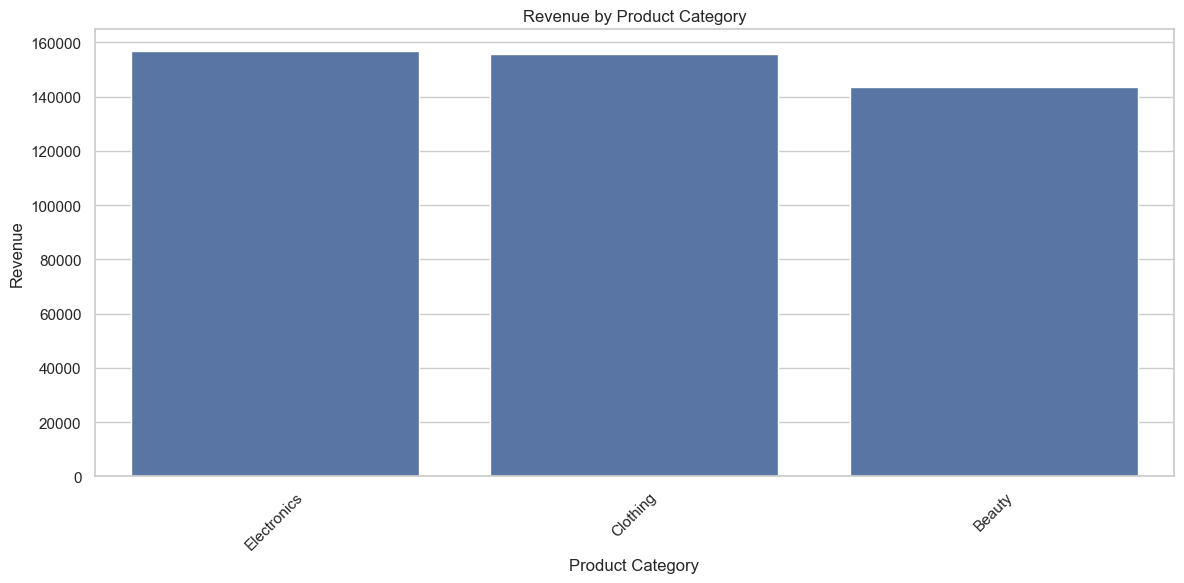

In [120]:
# =========================
# 11. REVENUE BY CATEGORY
# =========================
category_col="Product Category"
if category_col and sales_col:

    category_revenue = (
        df.groupby(category_col)[sales_col]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=category_revenue.index,
        y=category_revenue.values
    )

    plt.title("Revenue by Product Category")
    plt.xlabel("Product Category")
    plt.ylabel("Revenue")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

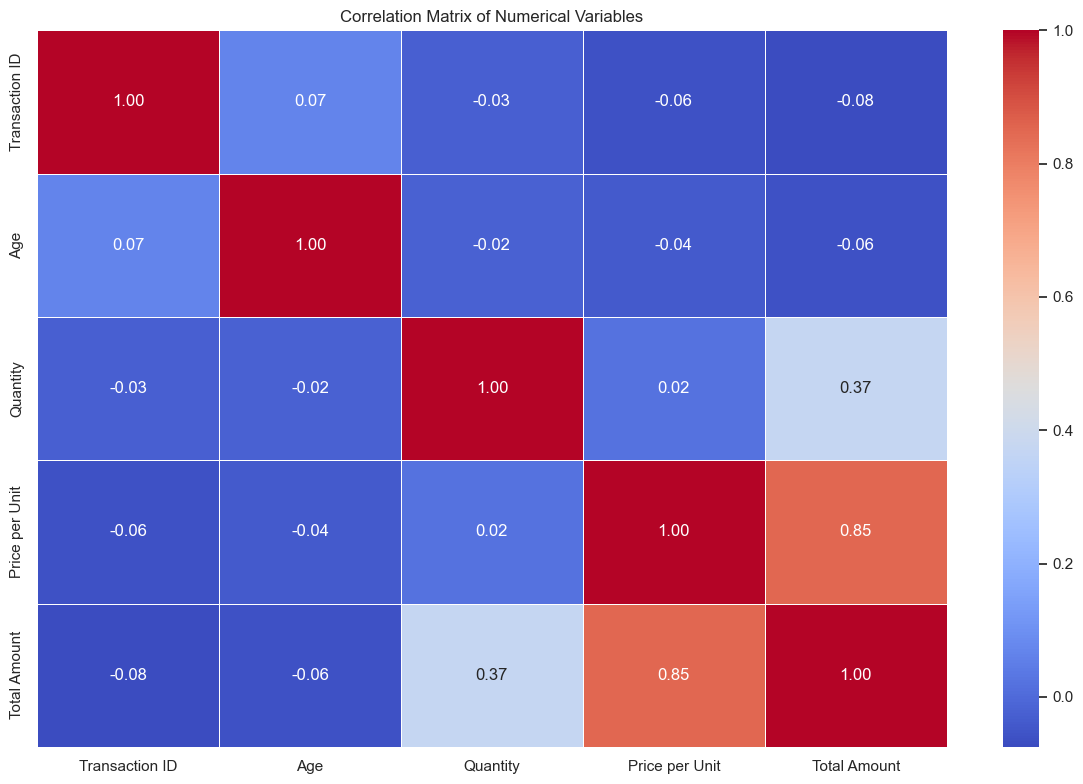

In [121]:
# =========================
# 12. CORRELATION HEATMAP
# =========================

numeric_data = df.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

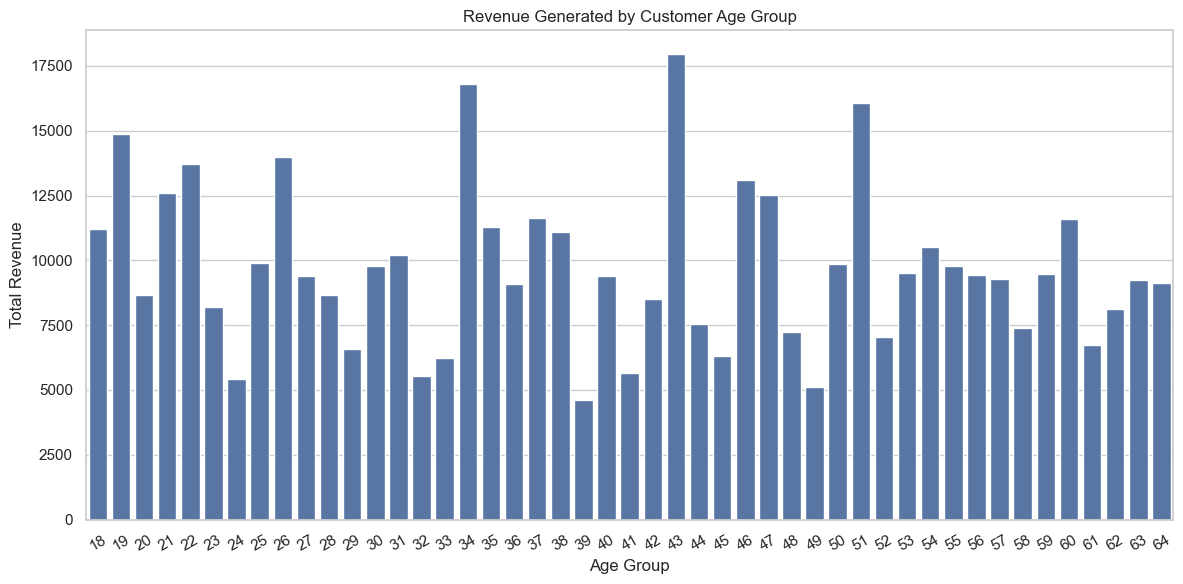

In [124]:
# =========================
# 13. ADDITIONAL VISUALIZATION
# SALES BY AGE GROUP
# =========================

if age_col and sales_col and "Age" in df.columns:

    age_sales = (
        df.groupby("Age", observed=True)[sales_col]
        .sum()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=age_sales.index,
        y=age_sales.values
    )

    plt.title("Revenue Generated by Customer Age Group")
    plt.xlabel("Age Group")
    plt.ylabel("Total Revenue")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

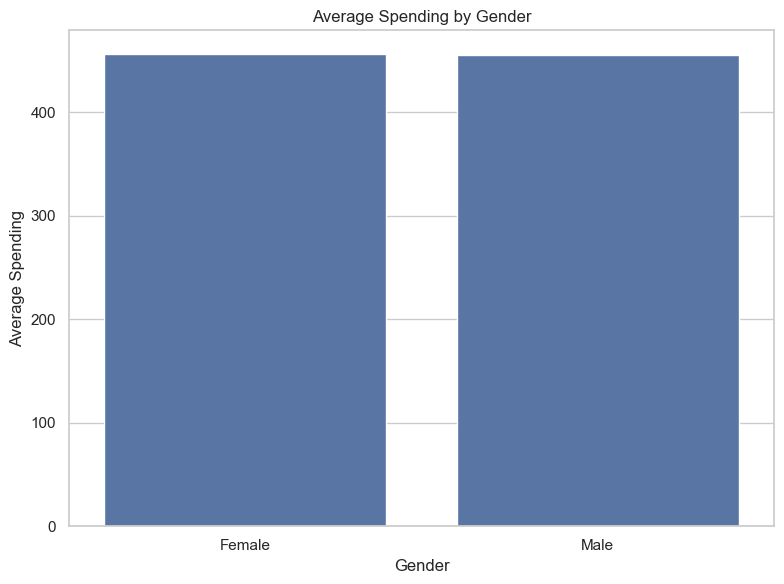

In [125]:
# =========================
# OPTIONAL ANALYSIS
# AVERAGE SPENDING BY GENDER
# =========================

if gender_col and sales_col:

    gender_spending = (
        df.groupby(gender_col)[sales_col]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8, 6))

    sns.barplot(
        x=gender_spending.index,
        y=gender_spending.values
    )

    plt.title("Average Spending by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Average Spending")

    plt.tight_layout()
    plt.show()

In [130]:
# =========================
# 15. KEY BUSINESS METRICS
# =========================

if sales_col:
    print("Total Revenue:", round(df[sales_col].sum(), 2))
    print("Average Transaction Value:", round(df[sales_col].mean(), 2))
    print("Median Transaction Value:", round(df[sales_col].median(), 2))

if quantity_col:
    print("Total Units Sold:", df[quantity_col].sum())

if product_col:
    print("Number of Products:", df[product_col].nunique())

if category_col:
    print("Number of Categories:", df[category_col].nunique())

if gender_col:
    print("Number of Gender Groups:", df[gender_col].nunique())

Total Revenue: 456000
Average Transaction Value: 456.0
Median Transaction Value: 135.0
Total Units Sold: 2514
Number of Products: 3
Number of Categories: 3
Number of Gender Groups: 2


In [129]:
# =========================
# BEST AND WORST MONTHS
# =========================

if date_col and sales_col:

    monthly_sales = (
        df.set_index(date_col)[sales_col]
        .resample('ME')
        .sum()
    )

    best_month = monthly_sales.idxmax()
    worst_month = monthly_sales.idxmin()

    print("Best Sales Month:")
    print(best_month.strftime("%B %Y"))
    print("Revenue:", round(monthly_sales.max(), 2))

    print("\nWorst Sales Month:")
    print(worst_month.strftime("%B %Y"))
    print("Revenue:", round(monthly_sales.min(), 2))

Best Sales Month:
May 2023
Revenue: 53150

Worst Sales Month:
January 2024
Revenue: 1530


# Conclusion and Business Recommendations

## Key Findings

The exploratory data analysis provided insights into sales trends,
customer demographics, product performance, and relationships between
numerical variables.

### 1. Improve Inventory Management
The top-selling products should receive priority when planning
inventory. Maintaining sufficient stock of high-demand products
can reduce missed sales caused by stock-outs.

### 2. Target High-Value Customer Segments
Customer age-group analysis can identify segments that generate
higher revenue. Marketing campaigns should focus more strongly on
high-value segments while developing strategies to increase spending
among lower-value segments.

### 3. Use Seasonal Sales Patterns
Monthly and quarterly sales trends can reveal periods of high and
low demand. The business should increase inventory and marketing
activities before high-demand periods and introduce promotions during
slow periods.

### 4. Focus on High-Revenue Product Categories
Categories generating the most revenue should receive appropriate
marketing and inventory investment. Lower-performing categories
should be reviewed to determine whether pricing, product quality,
customer demand, or product variety needs improvement.

### 5. Use Customer Data for Personalized Marketing
Customer demographic information can be used to create more
personalized promotions and product recommendations. Different
customer groups may respond differently to pricing, products, and
marketing campaigns.

## Overall Conclusion

The EDA demonstrates that retail sales data can be used to understand
customer behaviour, identify profitable products and categories,
recognize sales trends, and improve business decision-making.

The business should combine sales trends, customer demographics,
and product performance when making decisions about inventory,
marketing, promotions, and customer targeting.